# 0 - Helpers

In [4]:
from generate_country_comparison import *

# 1 - Retrieve networks

In [5]:
#years = [2025, 2030, 2035, 2040]
years = [2025, 2030]

# Main scenarios
scenarios_50 = ["baseline",
             "energy-match-50",
             #"hourly-match-50-90",
             #"hourly-match-50-95",
             #"hourly-match-50-98",
             #"hourly-match-50-99",
             ]


scenarios_25 = ["baseline",
             "energy-match-25",
             #"hourly-match-25-90",
             #"hourly-match-25-95",
             #"hourly-match-25-98",
             #"hourly-match-25-99",
             ]

# Load all networks
scenarios_all = {"main_CI_50": scenarios_50,
                 #"main_CI_25": scenarios_25,
                 }

df_networks_all = {}

for group, scenarios in scenarios_all.items():

    # Build MultiIndex
    index = pd.MultiIndex.from_product(
        [years, scenarios],
        names=["year", "scenario"]
    )

    # Create empty DataFrame
    df_networks = pd.DataFrame(index=index, columns=["network"])

    # Fill it
    for year, sc in index:
        try:
            n = pypsa.Network(f"../results/{sc}/networks/base_s_39___{year}.nc")
        except:
            print(f"{sc}-{year} not availabe")
            continue
        n = prepare_network(n)
        n.name = f"{sc}-{year}"
        df_networks.loc[(year, sc), "network"] = n

        m = strip_network_GoO(n)
        m.name = "GoO-" + m.name
        df_networks.loc[(year, sc), "GoO"] = m

    df_networks = df_networks.dropna()
    df_networks_all[group] = df_networks

# Calculate figsize automatically based on number of years
figsize_bar_countries = FIGSIZE_BAR_COUNTRIES  # Fixed size for resource utilization bar plot
print(f"Using figsize for resource utilization bar plot: {figsize_bar_countries}")

# Combine all networks from different groups into a single DataFrame
df_networks = pd.concat([df for df in df_networks_all.values()], axis=0)
df_networks = df_networks[~df_networks.index.duplicated(keep='first')]

INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.5 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


Using figsize for resource utilization bar plot: (12, 6)


# 2 - Generate country comparison figures


Generating figure a
-------------------------------------Analyzing (2025, 'baseline')


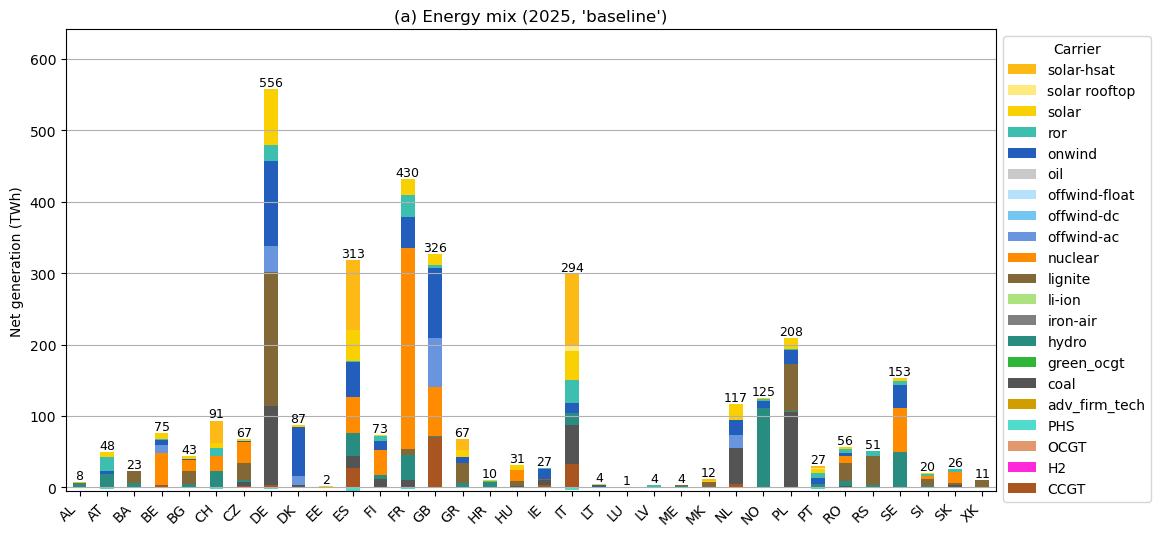

-------------------------------------Analyzing (2025, 'energy-match-50')


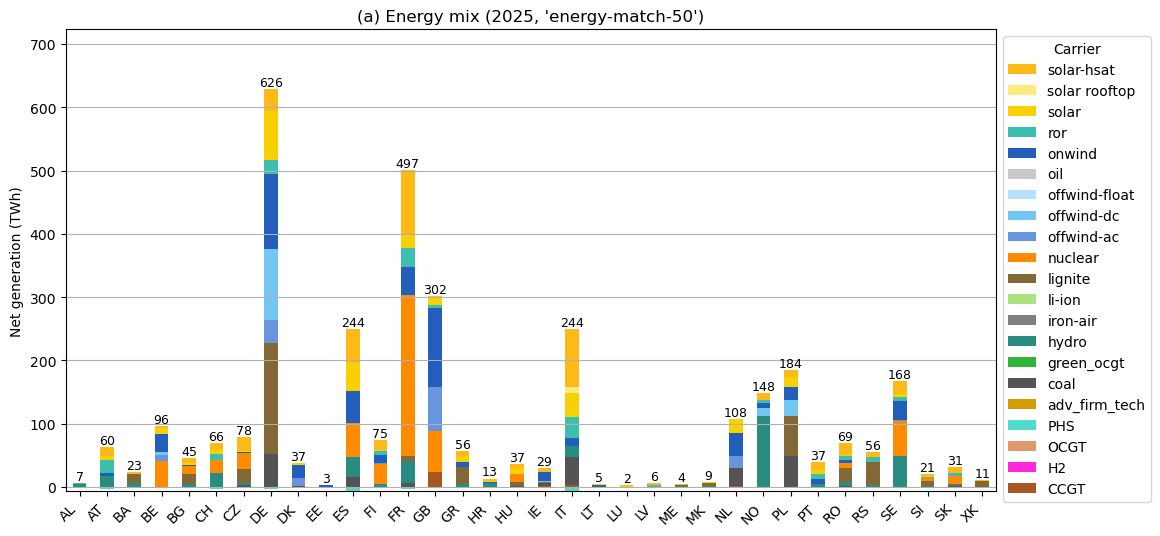

-------------------------------------Analyzing (2030, 'baseline')


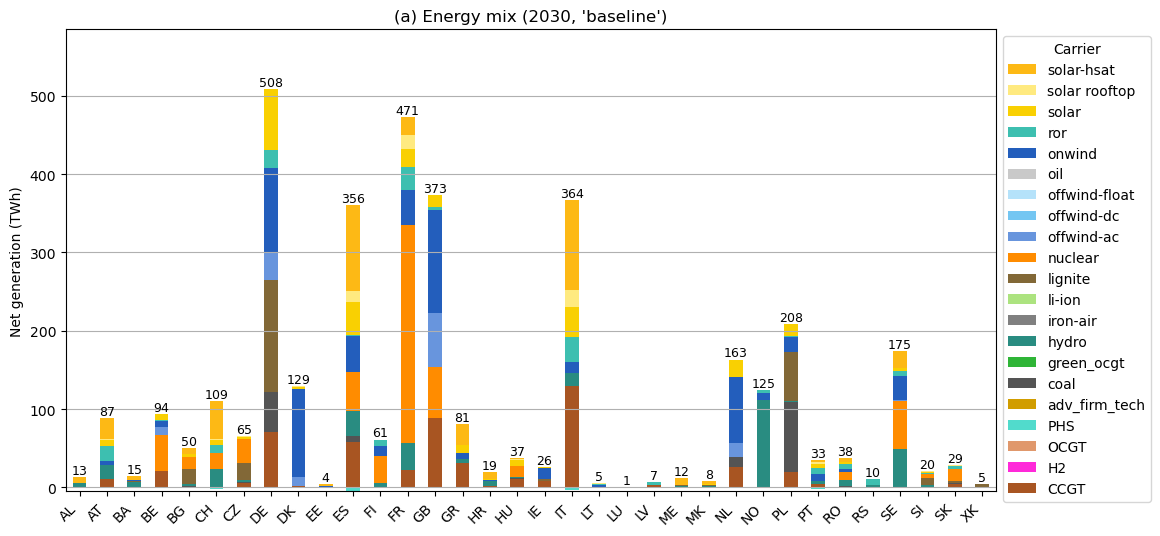

-------------------------------------Analyzing (2030, 'energy-match-50')


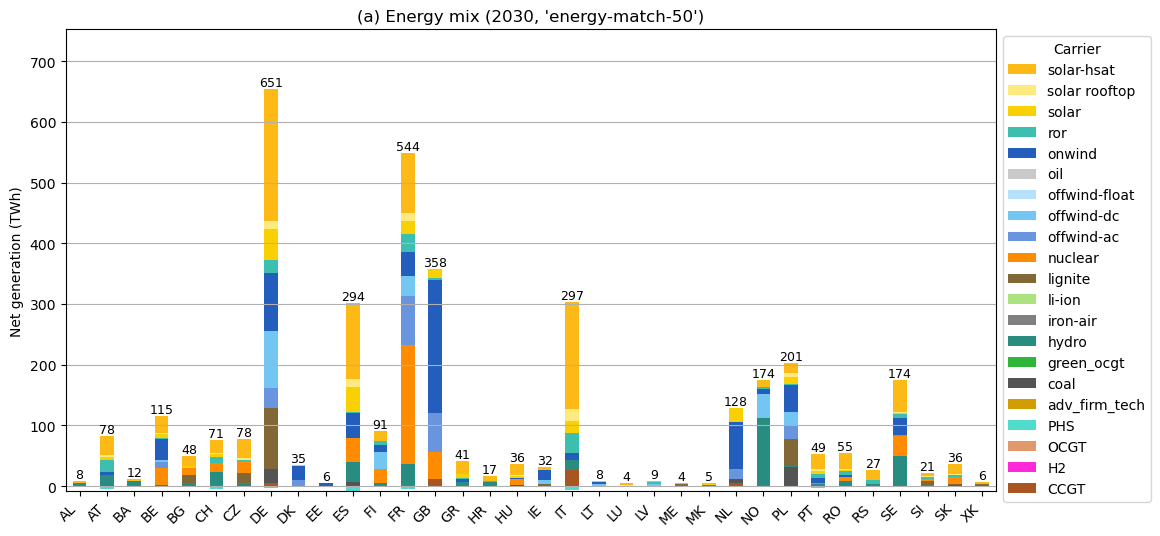


Generating figure b
-------------------------------------Analyzing (2025, 'energy-match-50')


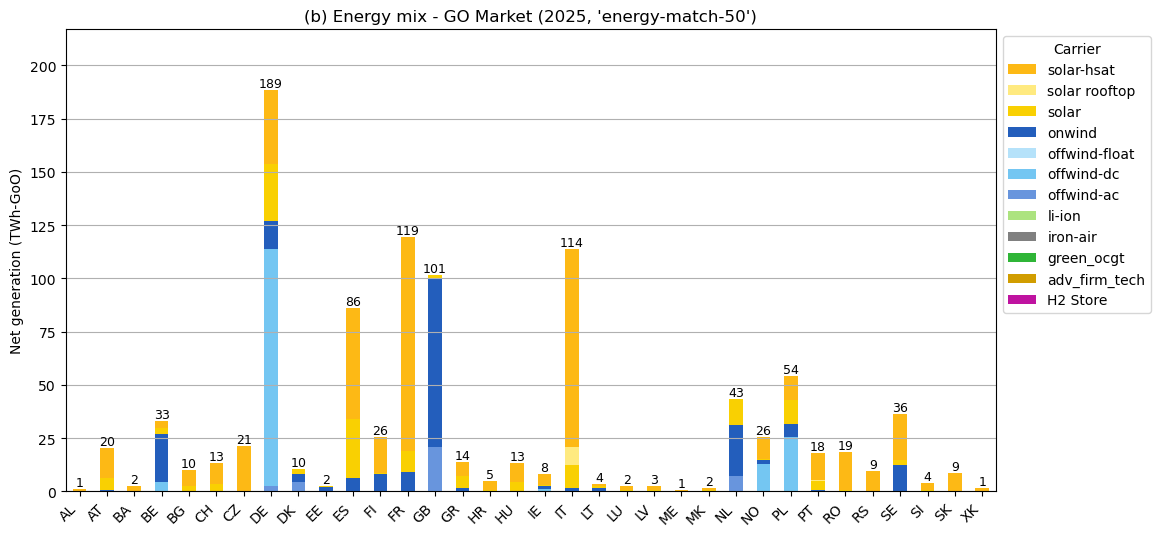

-------------------------------------Analyzing (2030, 'energy-match-50')


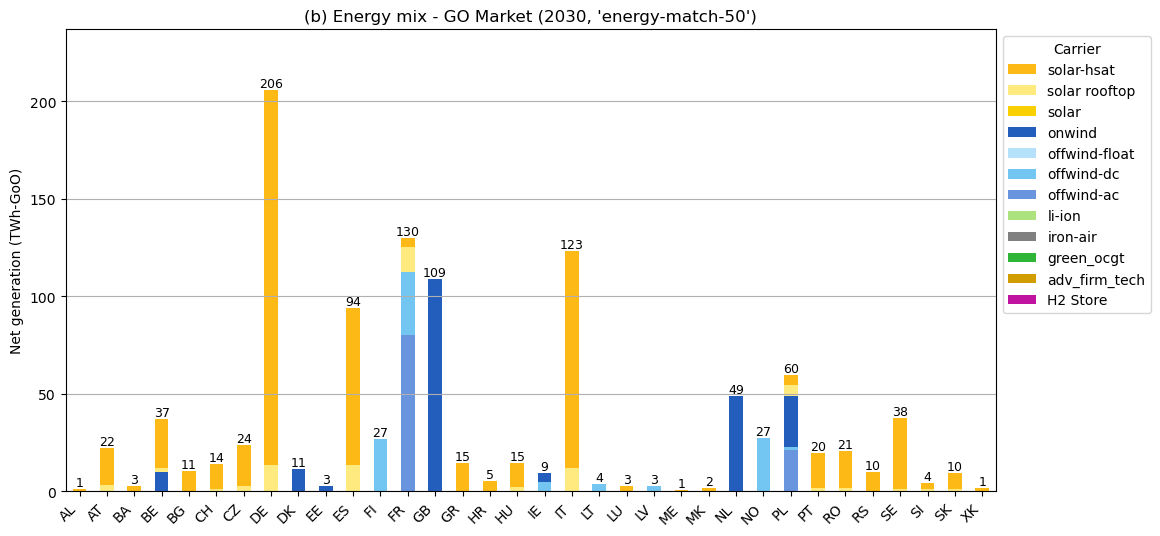


Generating figure c
-------------------------------------Analyzing (2025, 'baseline')


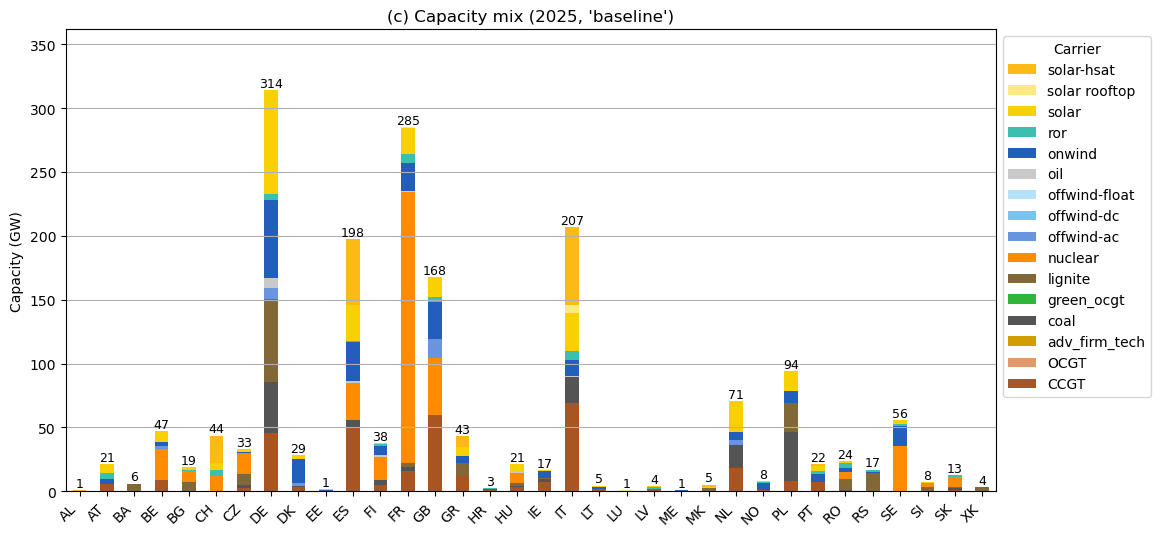

-------------------------------------Analyzing (2025, 'energy-match-50')


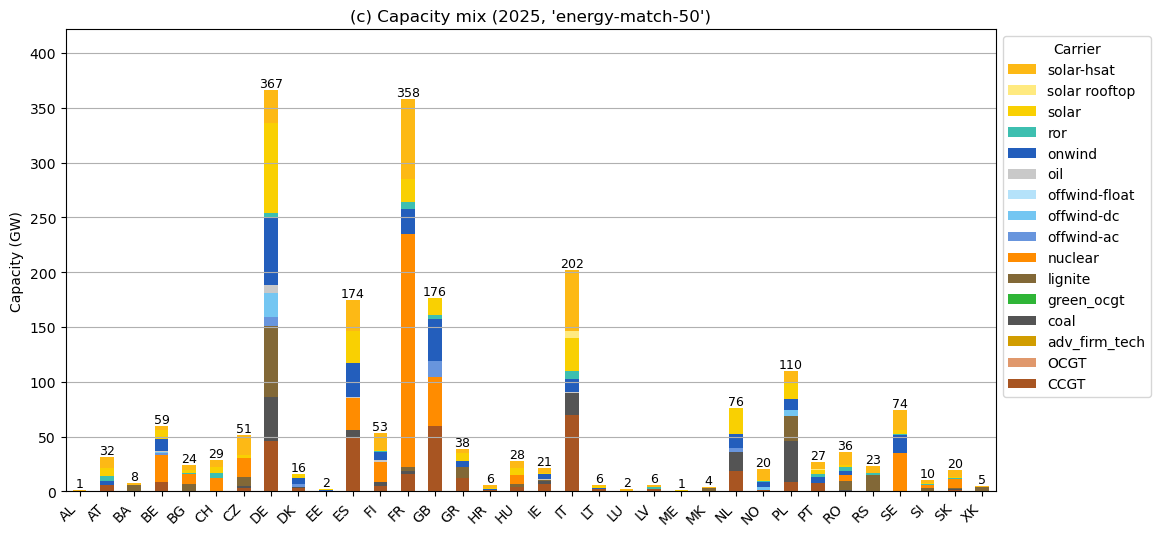

-------------------------------------Analyzing (2030, 'baseline')


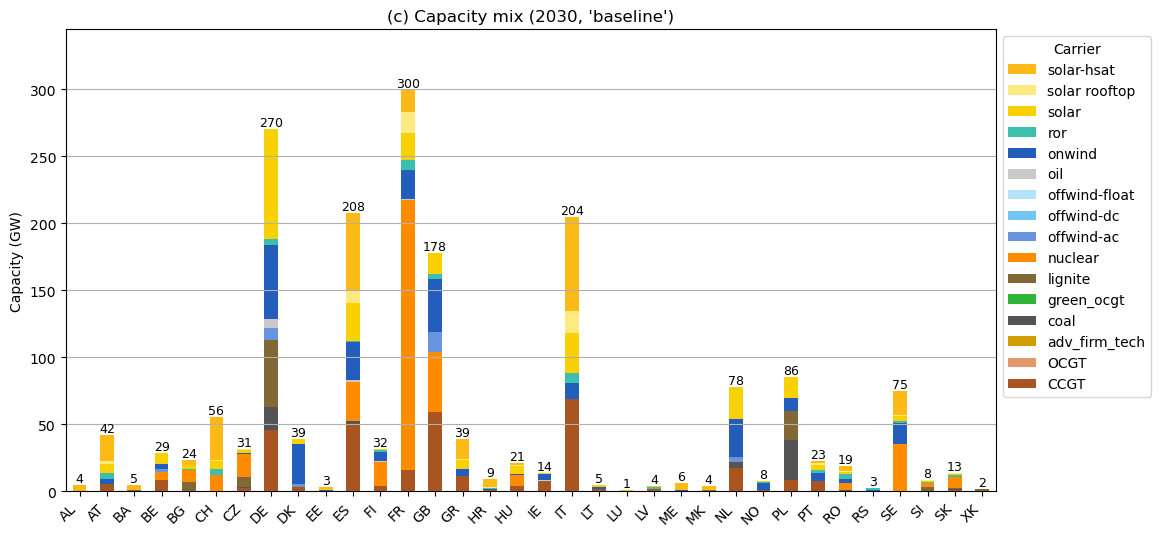

-------------------------------------Analyzing (2030, 'energy-match-50')


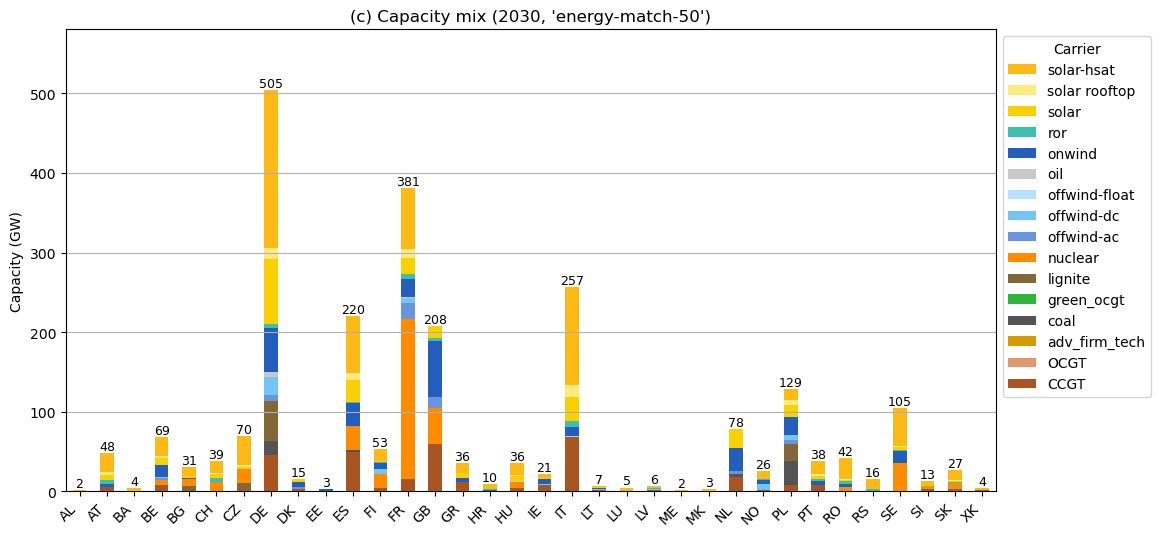


Generating figure d
-------------------------------------Analyzing (2025, 'baseline')


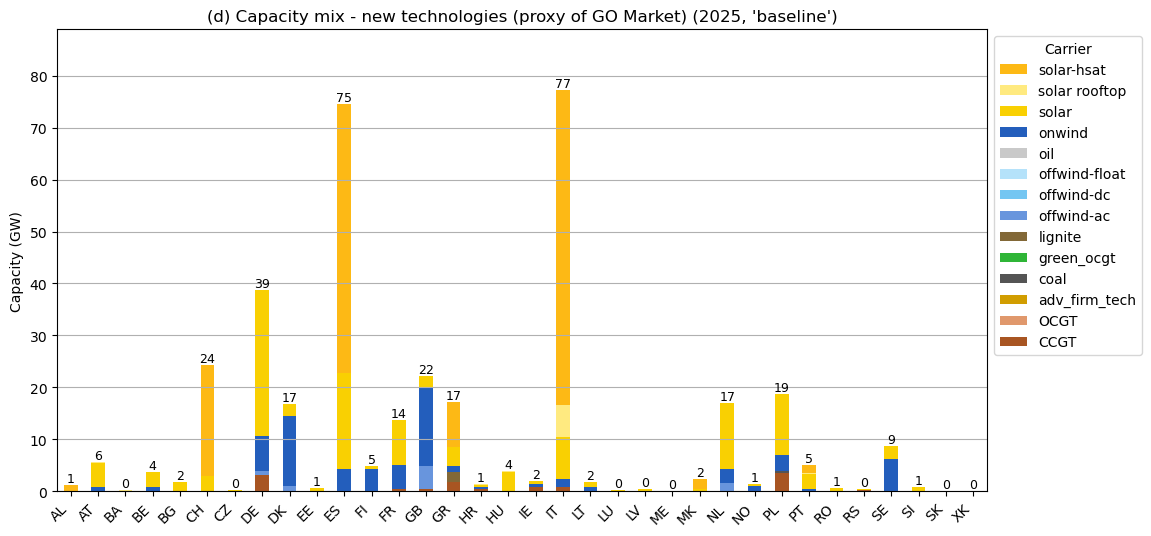

-------------------------------------Analyzing (2025, 'energy-match-50')


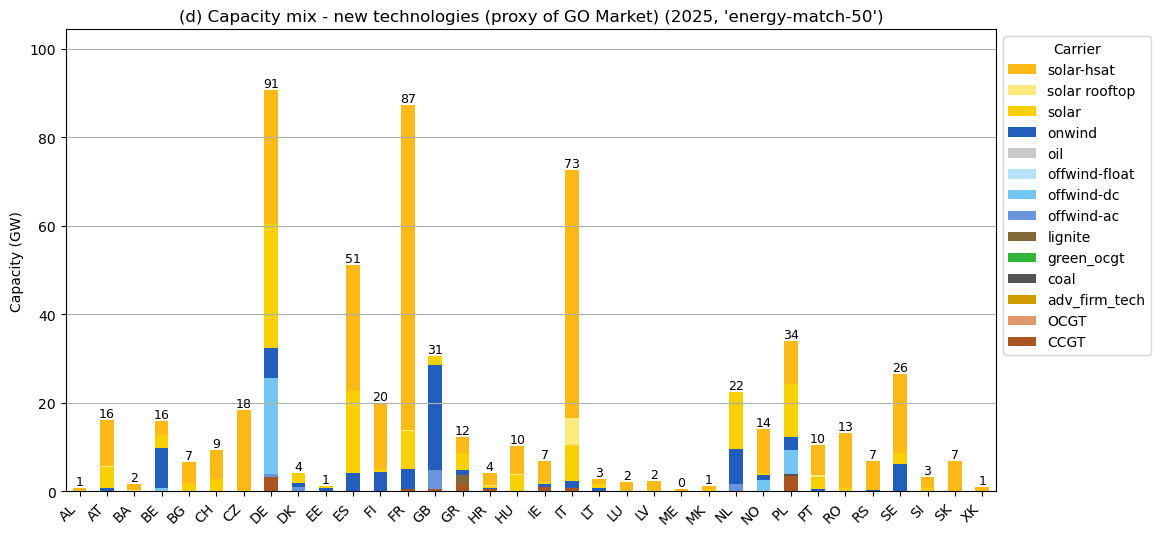

-------------------------------------Analyzing (2030, 'baseline')


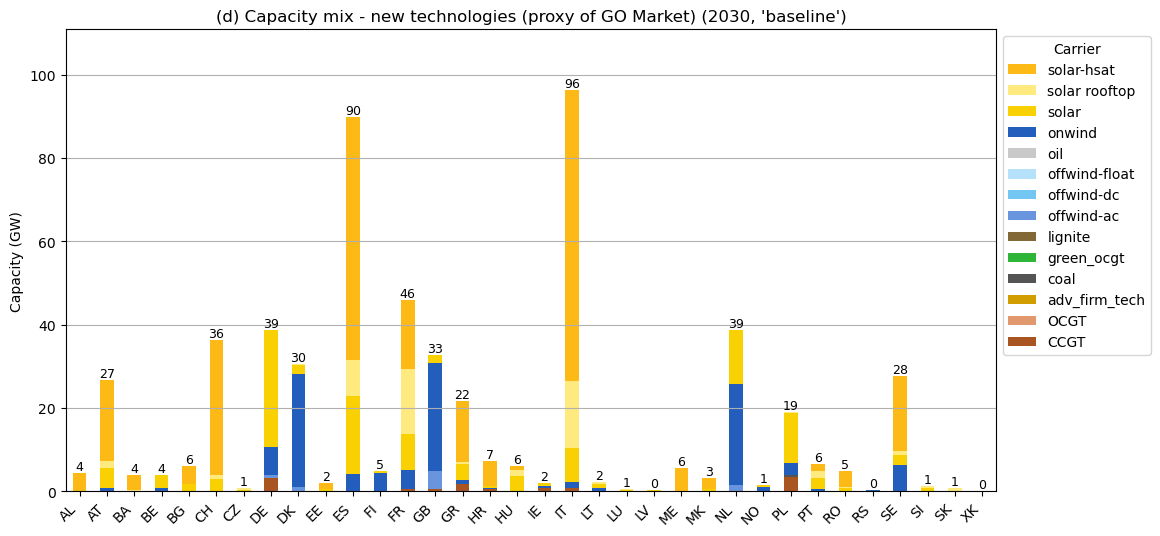

-------------------------------------Analyzing (2030, 'energy-match-50')


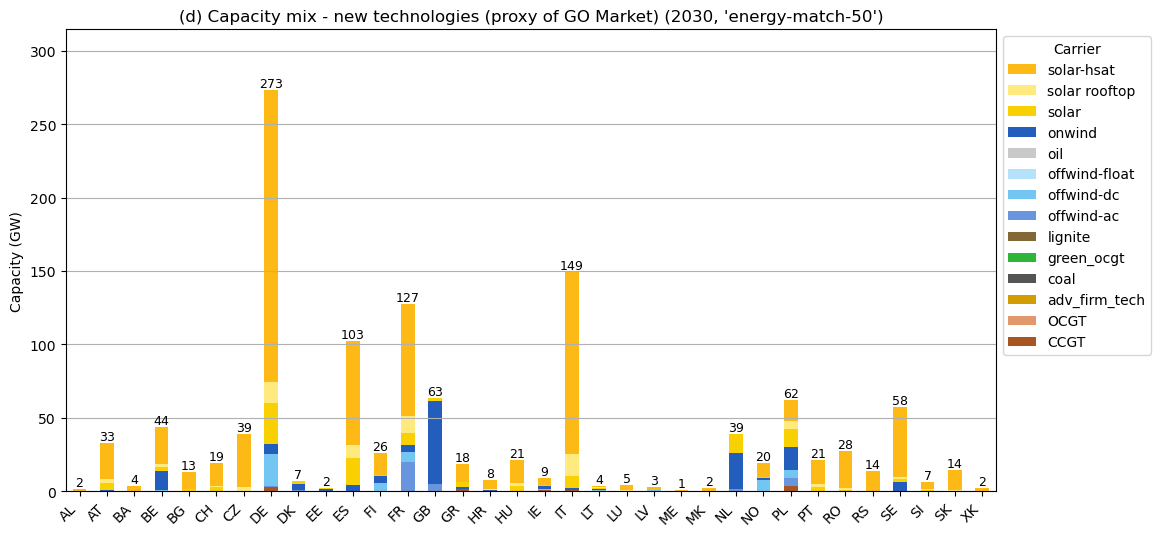


Generating figure e1
-------------------------------------Analyzing (2025, 'baseline')


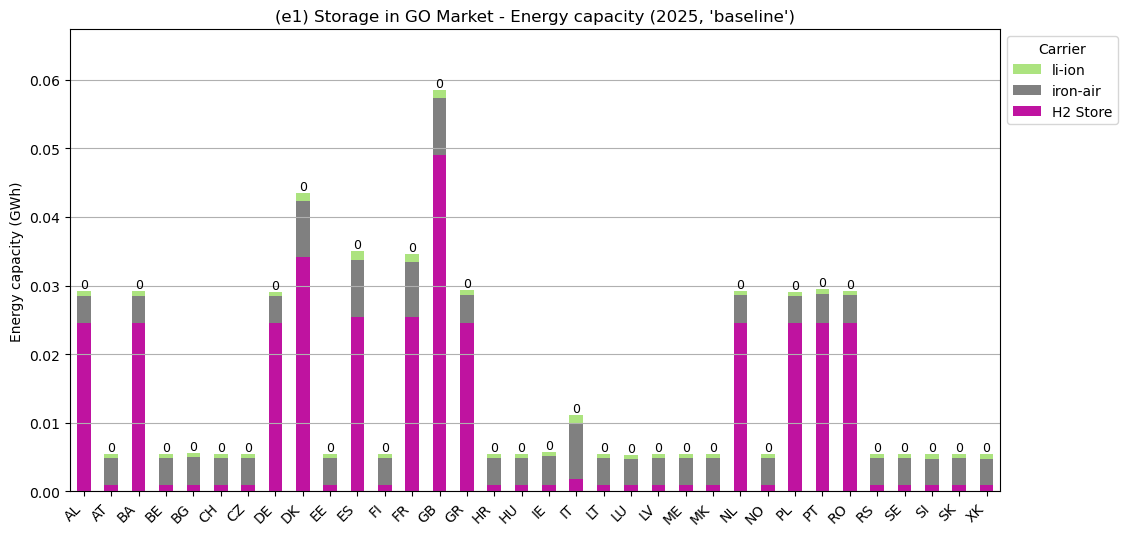

-------------------------------------Analyzing (2025, 'energy-match-50')


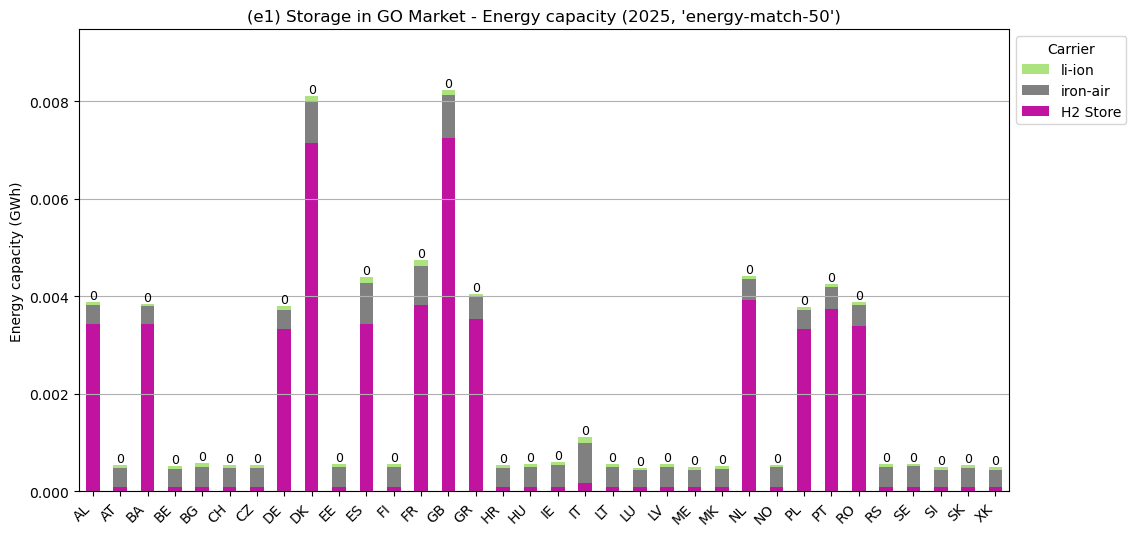

-------------------------------------Analyzing (2030, 'baseline')


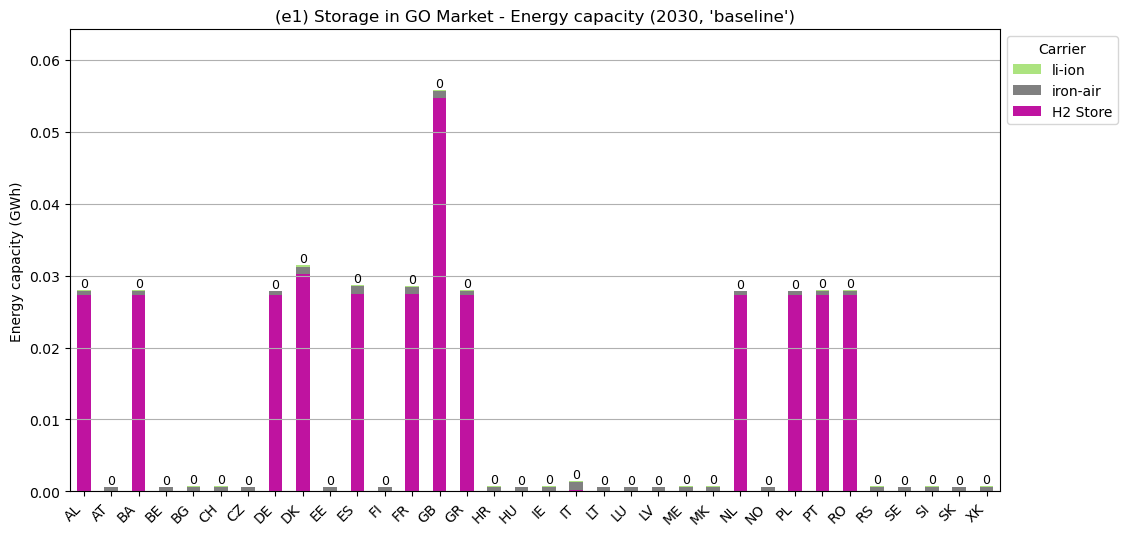

-------------------------------------Analyzing (2030, 'energy-match-50')


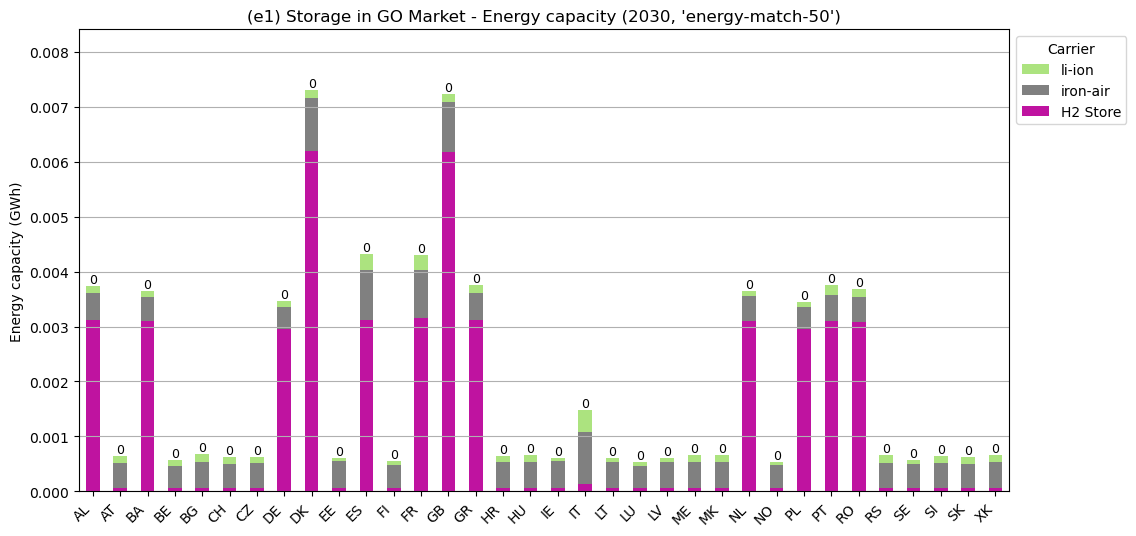


Generating figure e2
-------------------------------------Analyzing (2025, 'baseline')


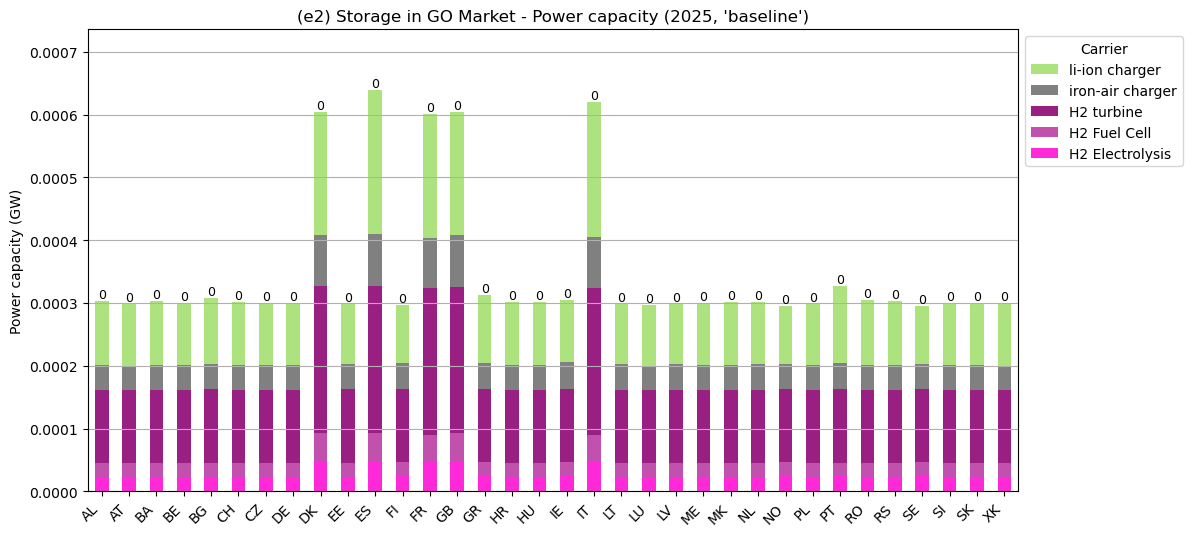

-------------------------------------Analyzing (2025, 'energy-match-50')


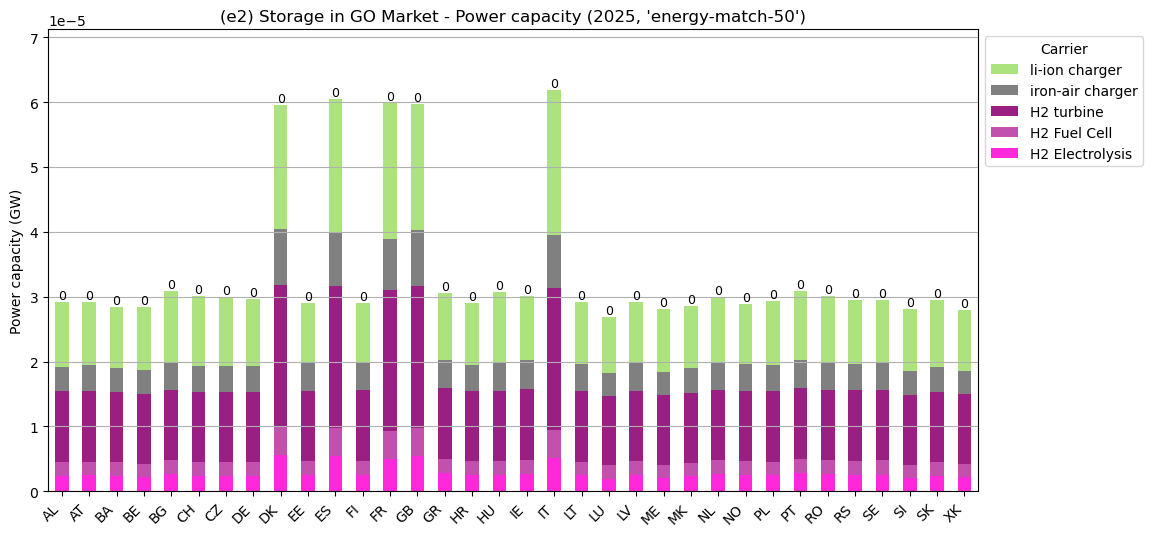

-------------------------------------Analyzing (2030, 'baseline')


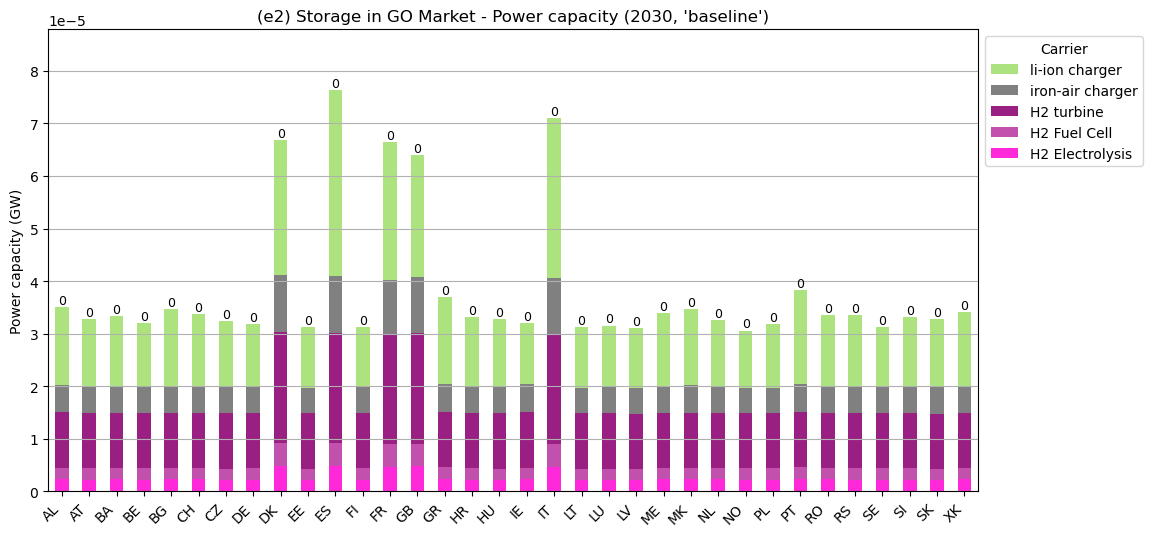

-------------------------------------Analyzing (2030, 'energy-match-50')


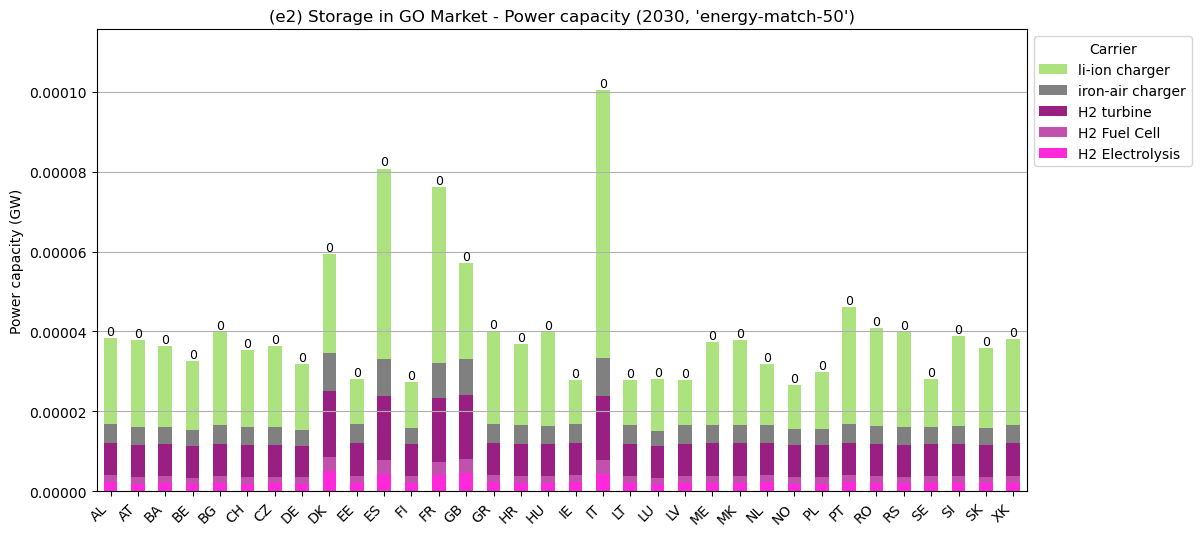


Generating figure g
-------------------------------------Analyzing (2025, 'baseline')


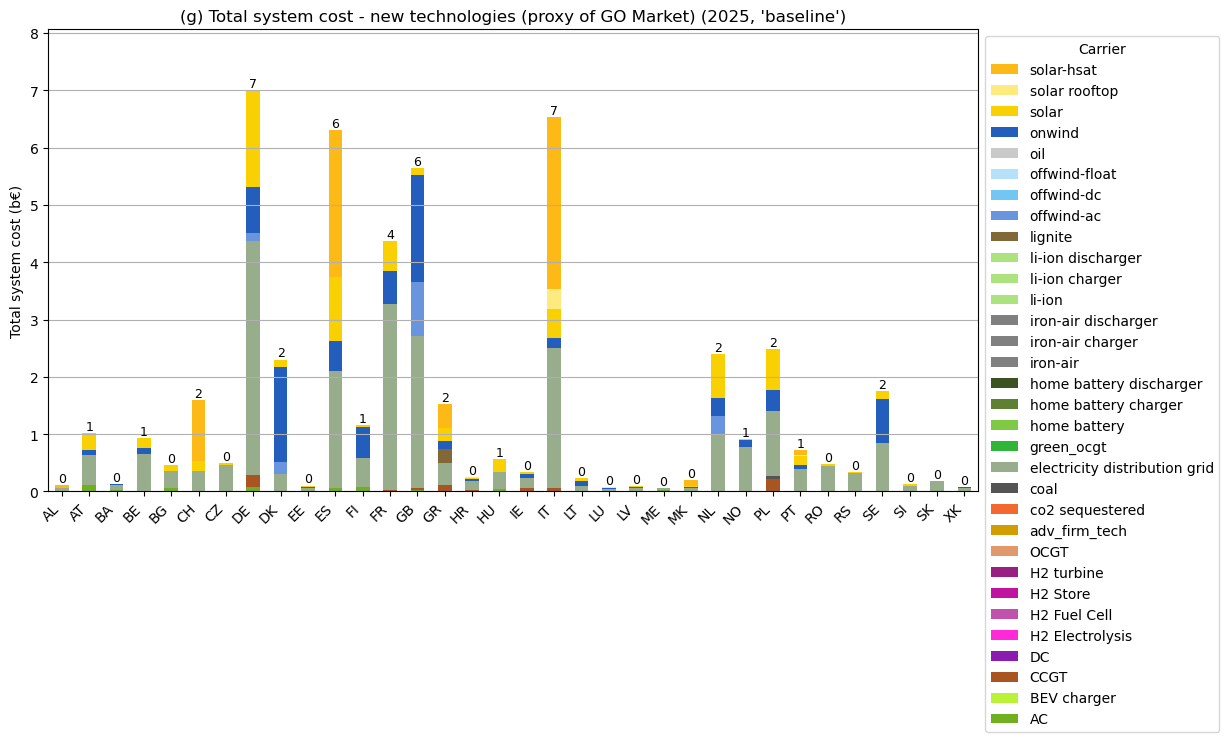

-------------------------------------Analyzing (2025, 'energy-match-50')


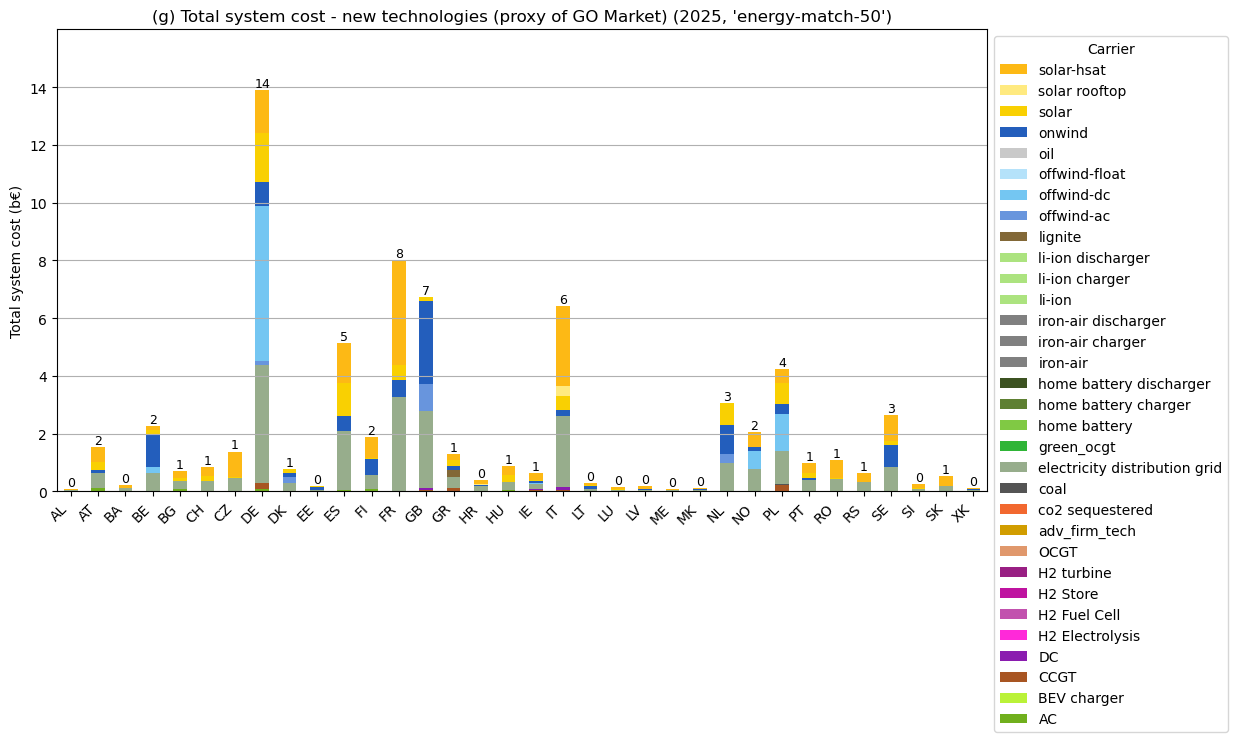

-------------------------------------Analyzing (2030, 'baseline')


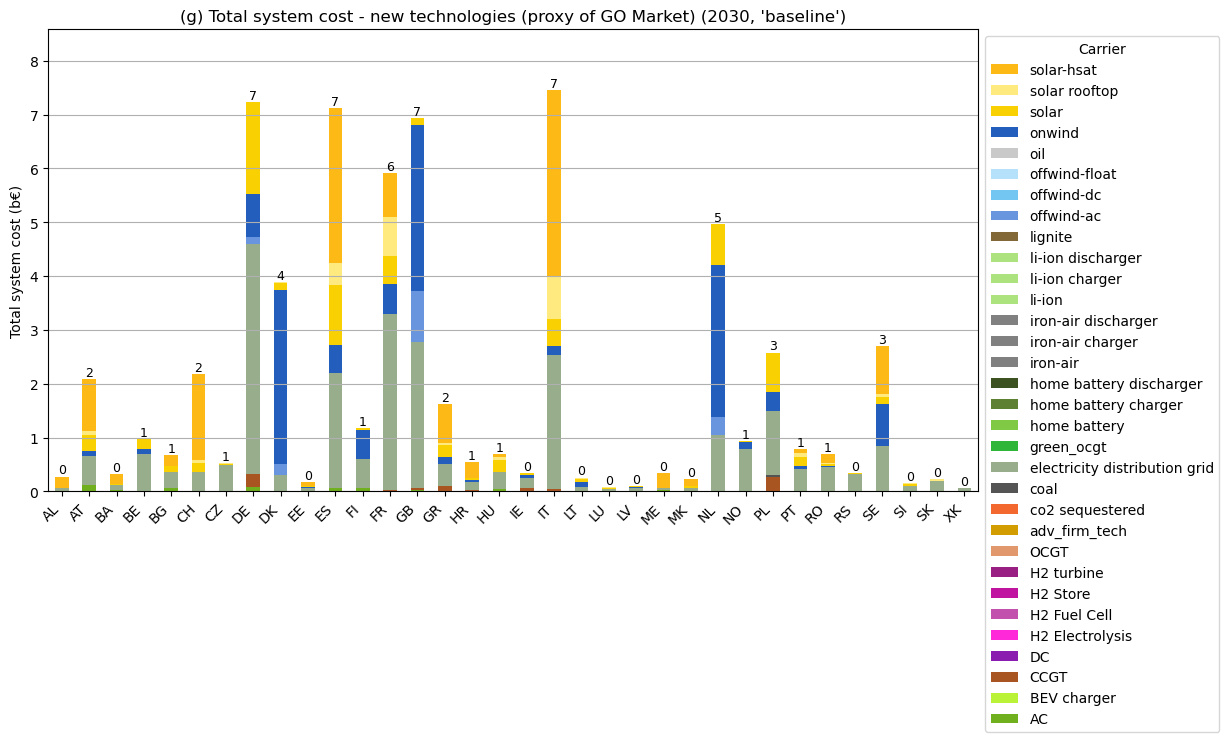

-------------------------------------Analyzing (2030, 'energy-match-50')


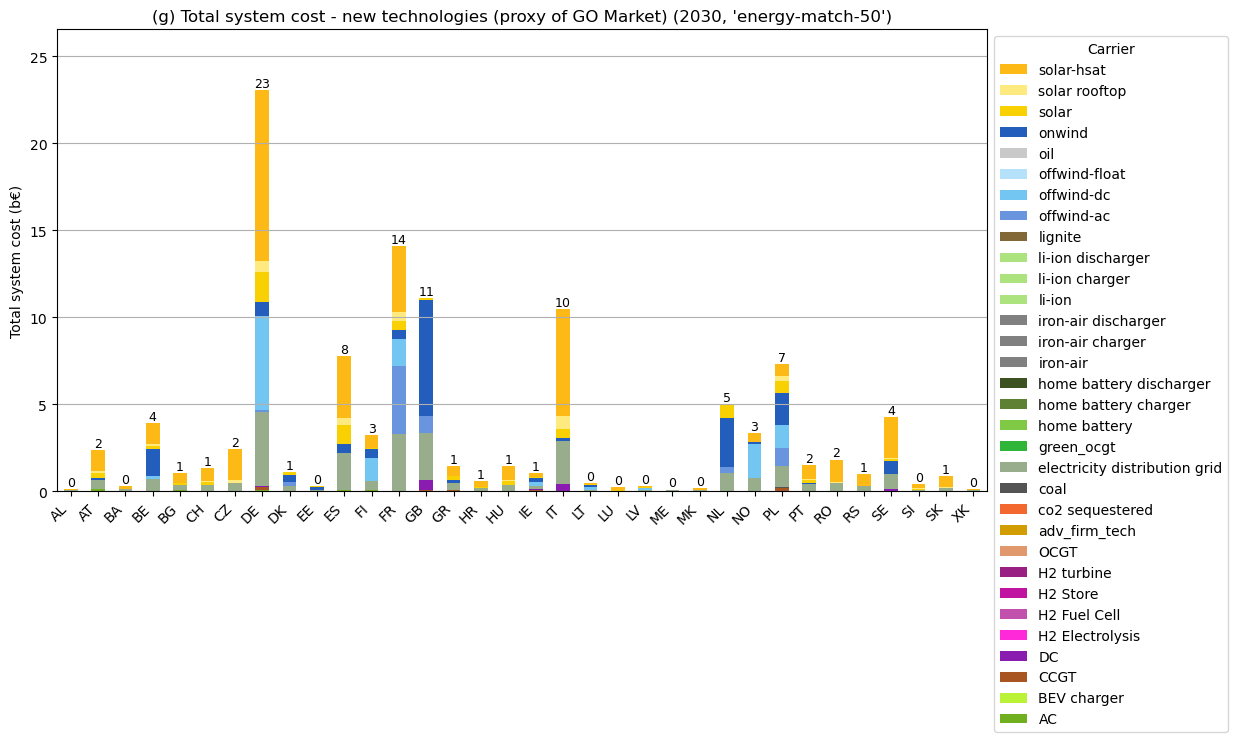


Generating figure h
-------------------------------------Analyzing (2025, 'energy-match-50')


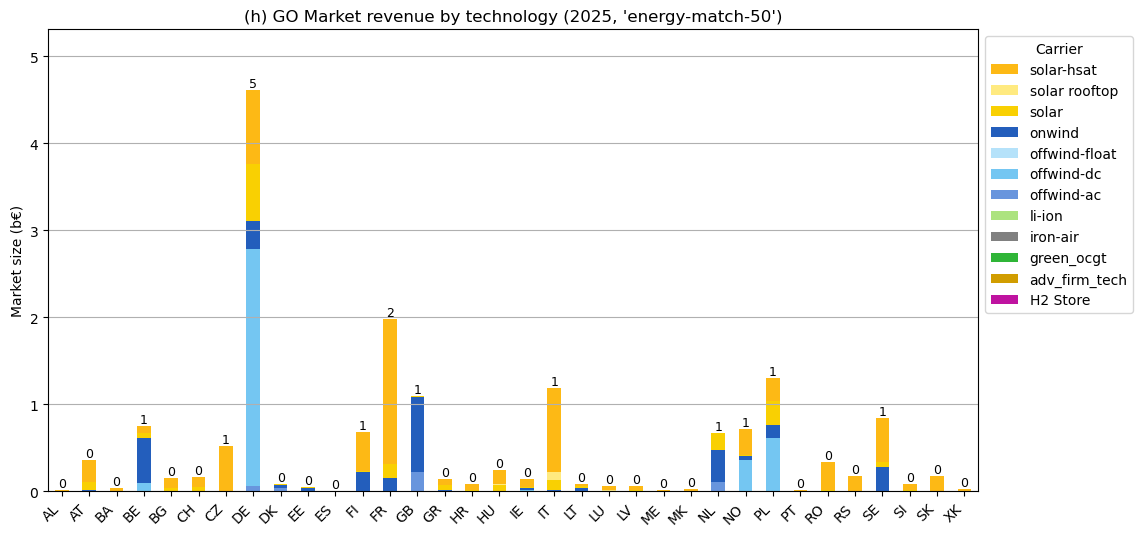

-------------------------------------Analyzing (2030, 'energy-match-50')


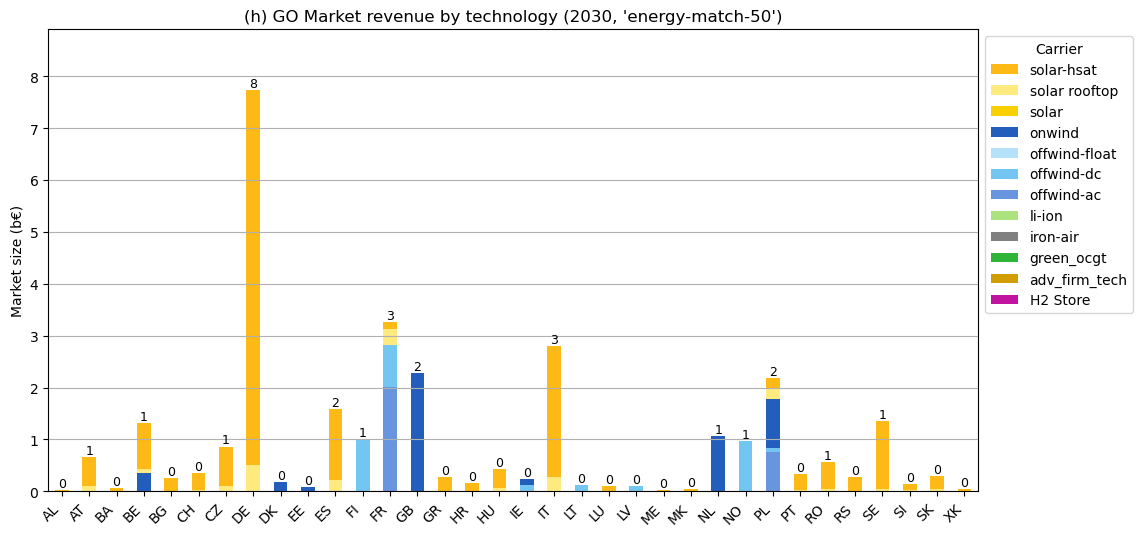


Generating figure i
-------------------------------------Analyzing (2025, 'baseline')


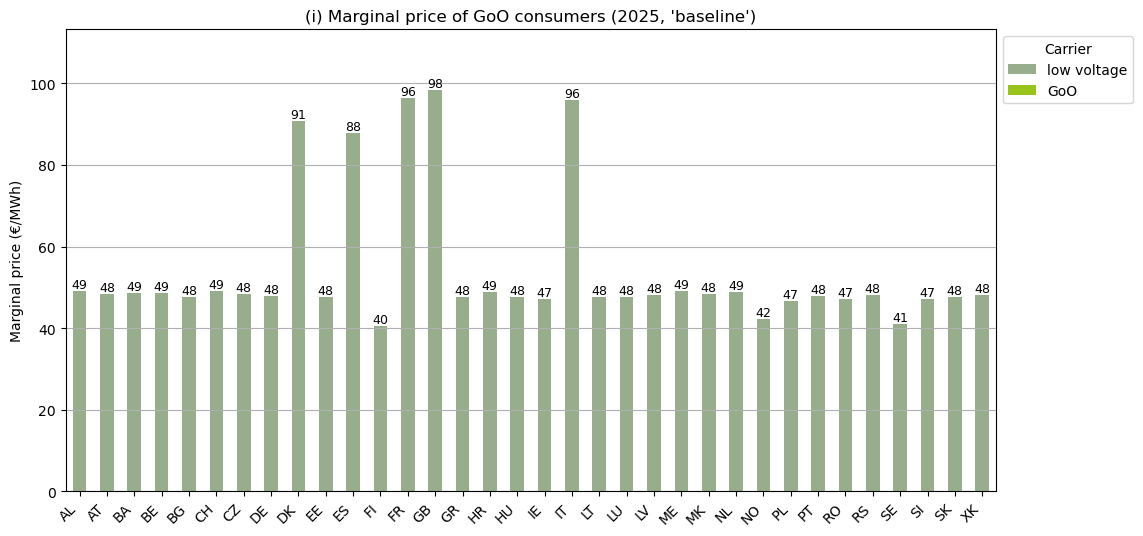

-------------------------------------Analyzing (2025, 'energy-match-50')


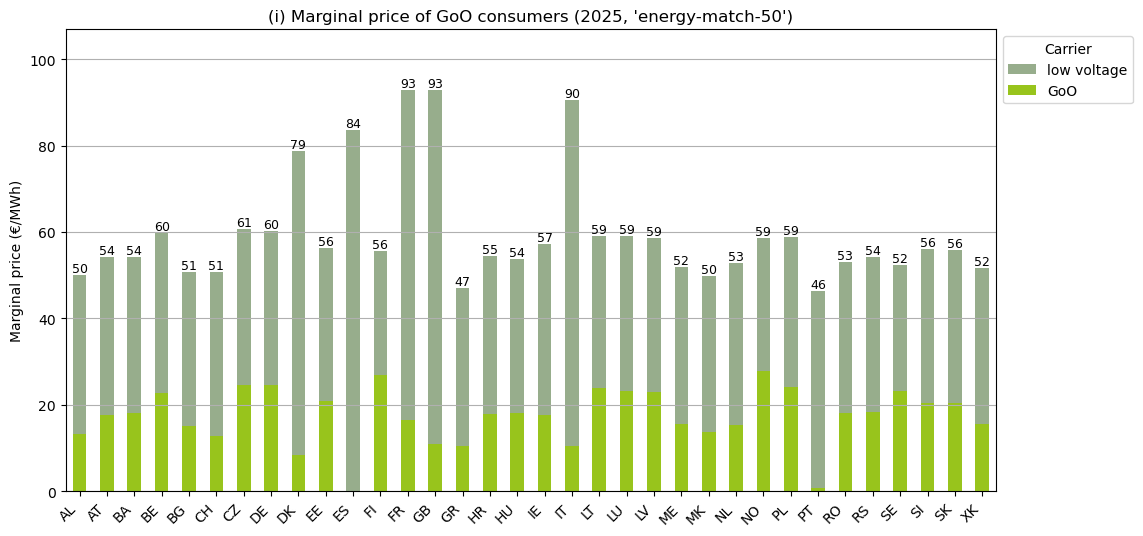

-------------------------------------Analyzing (2030, 'baseline')


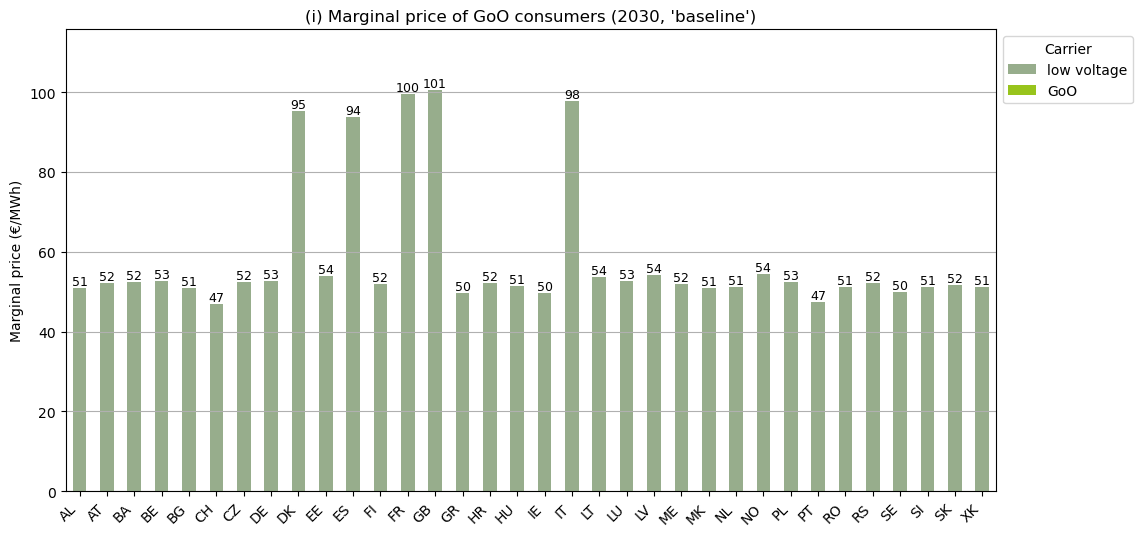

-------------------------------------Analyzing (2030, 'energy-match-50')


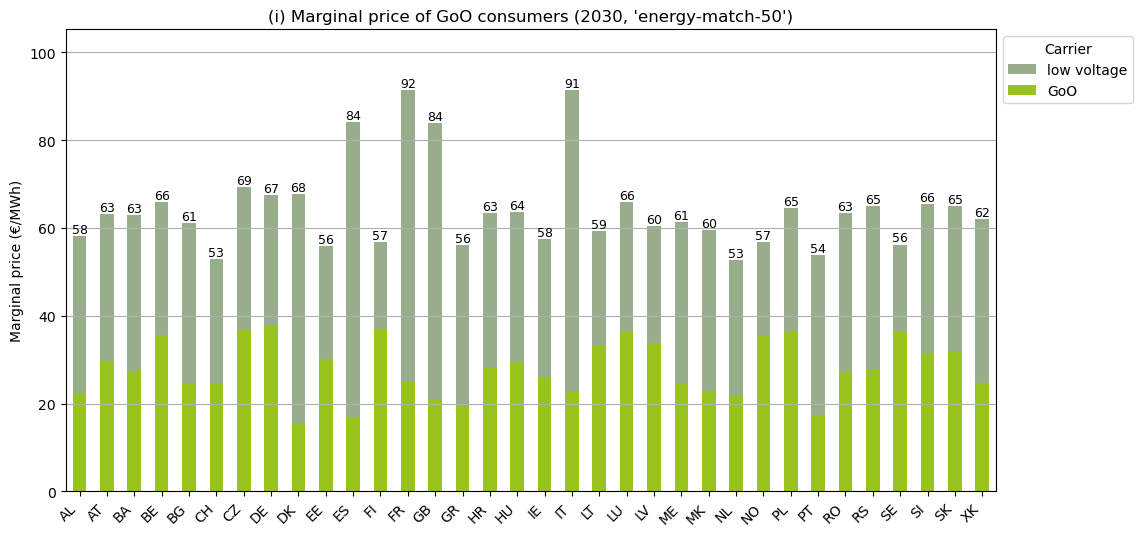


Generating figure j
-------------------------------------Analyzing (2025, 'baseline')


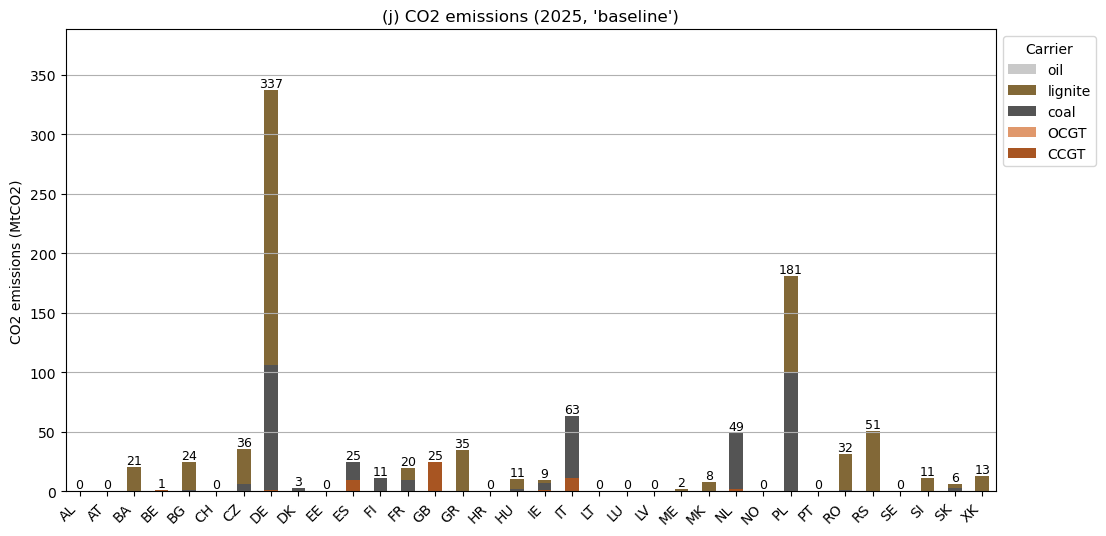

-------------------------------------Analyzing (2025, 'energy-match-50')


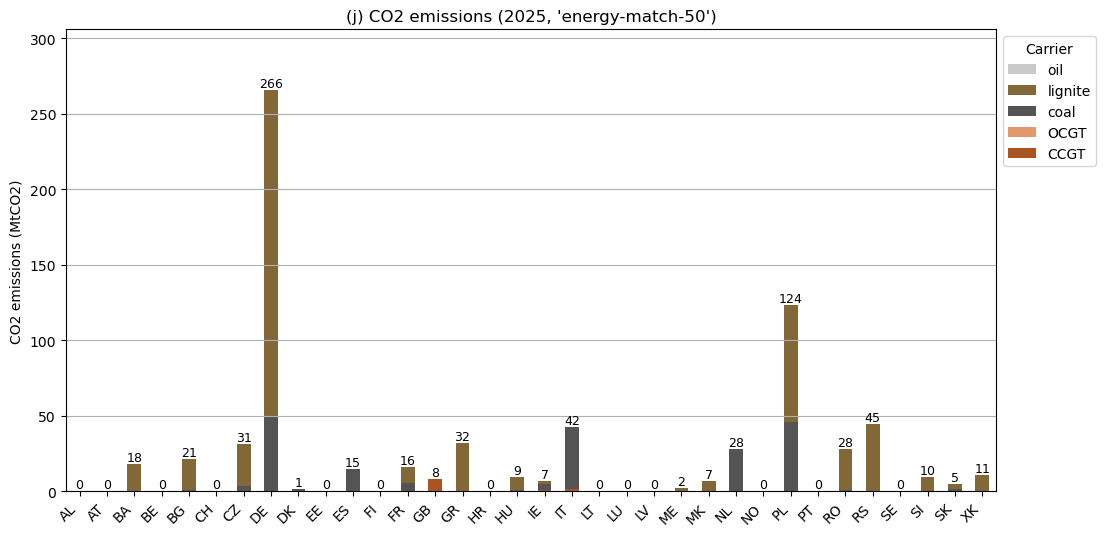

-------------------------------------Analyzing (2030, 'baseline')


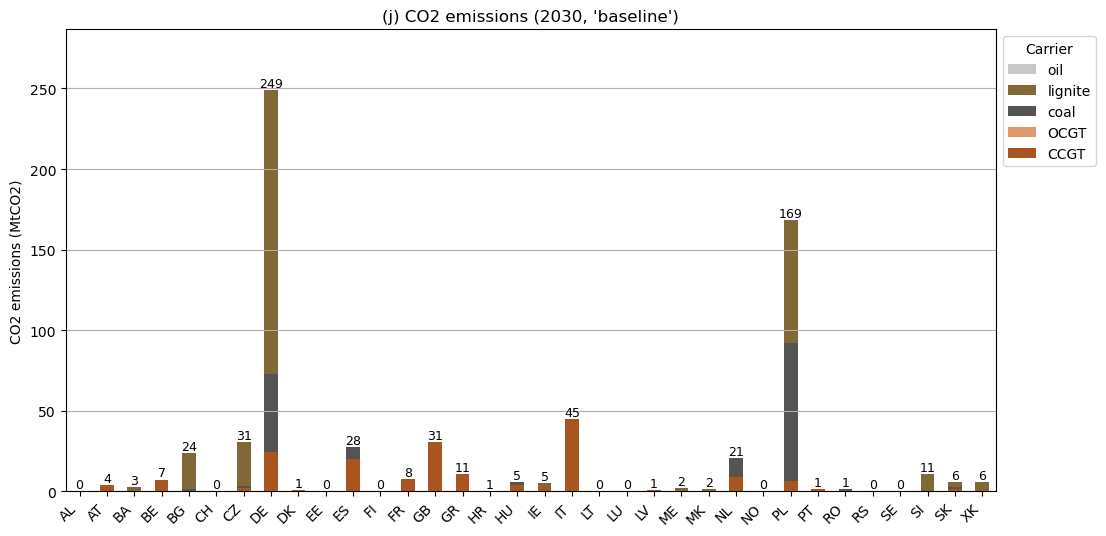

-------------------------------------Analyzing (2030, 'energy-match-50')


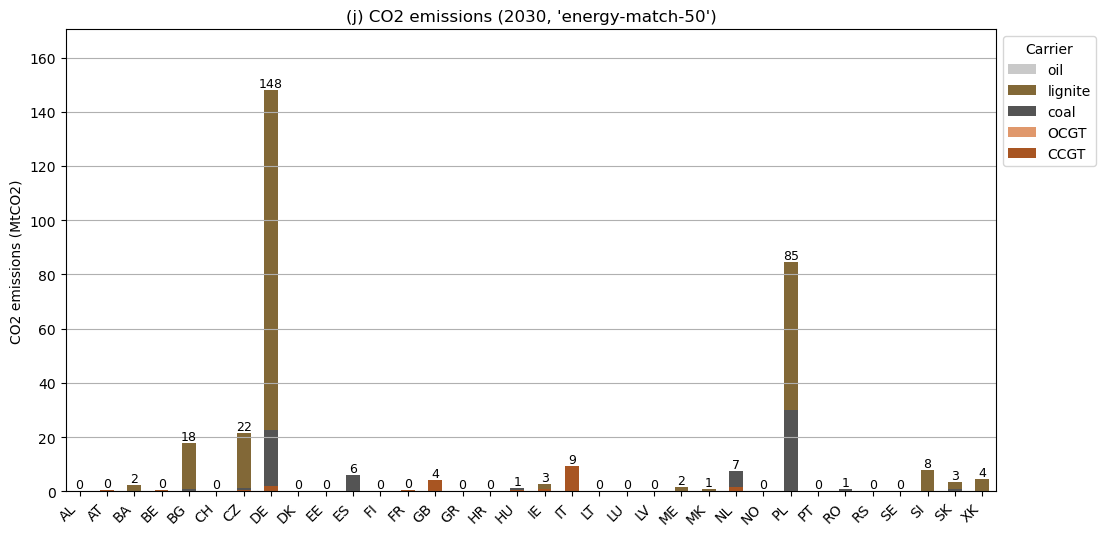


Generating figure k
-------------------------------------Analyzing (2025, 'baseline')


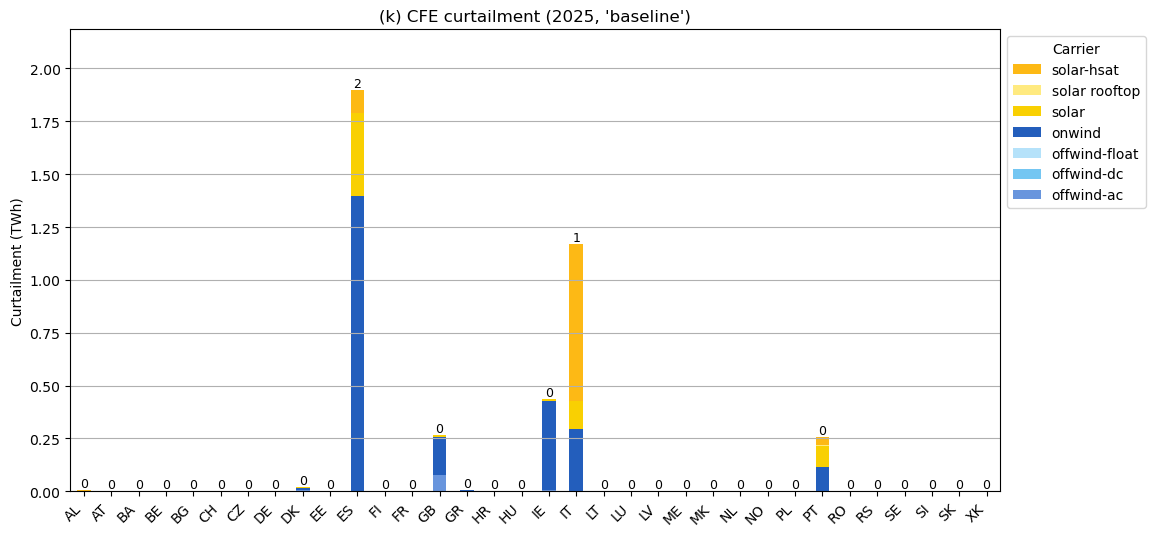

-------------------------------------Analyzing (2025, 'energy-match-50')


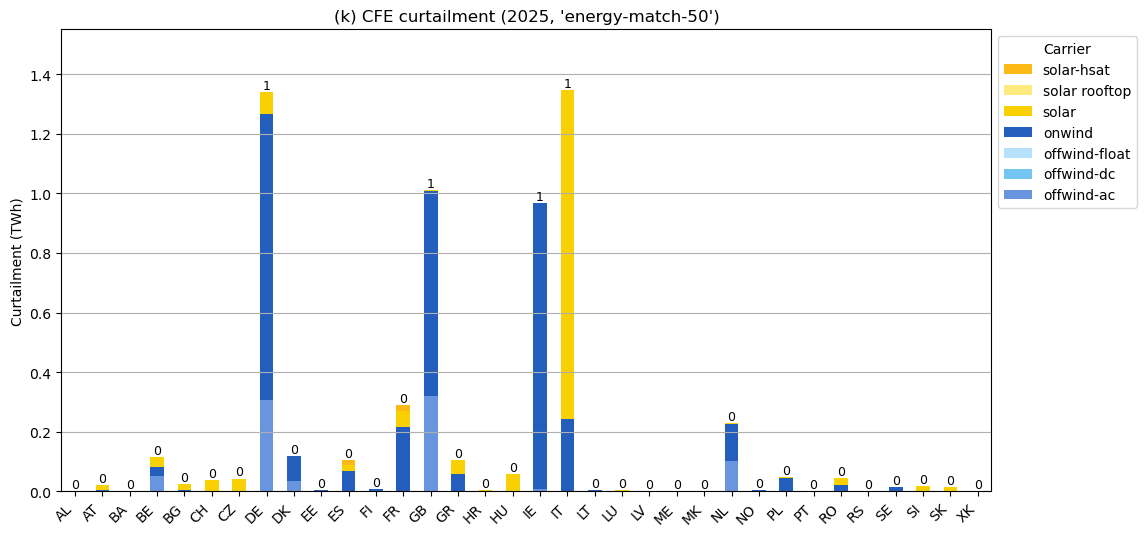

-------------------------------------Analyzing (2030, 'baseline')


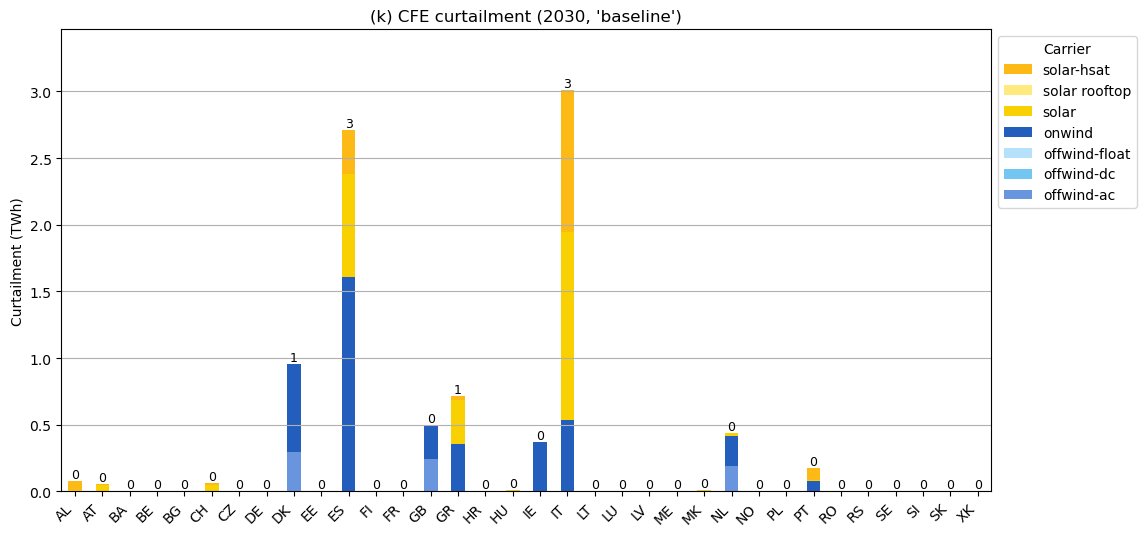

-------------------------------------Analyzing (2030, 'energy-match-50')


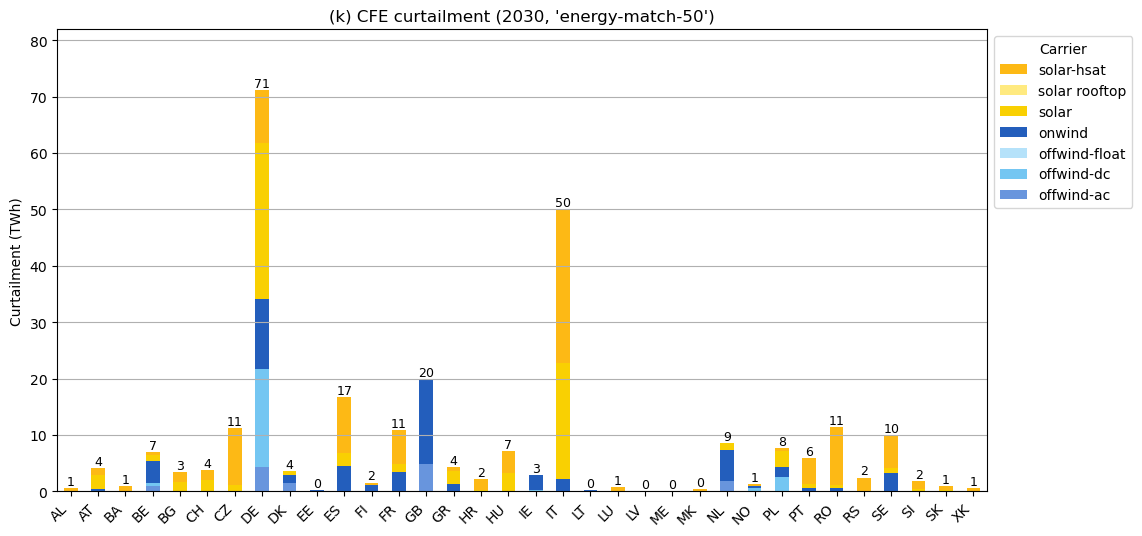


Generating figure b_map


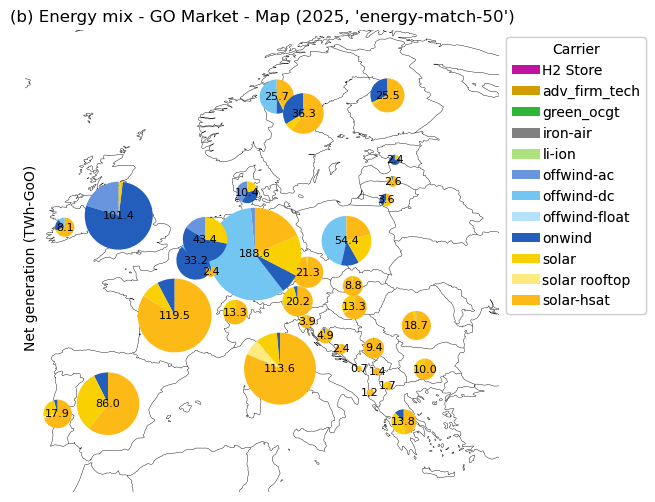

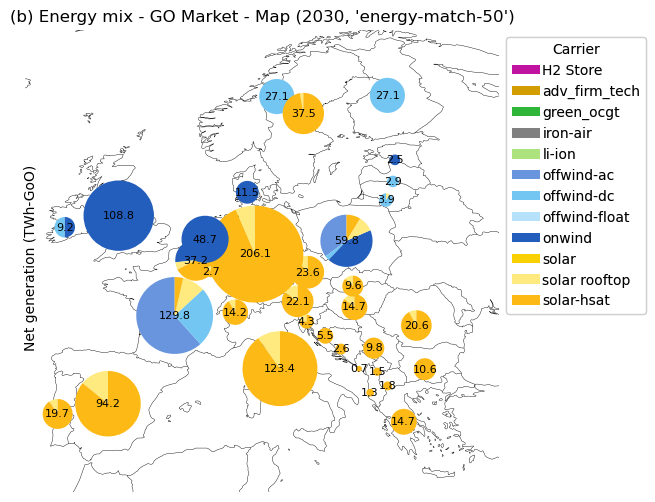

In [6]:
figures_to_generate = [
    'a',    # derive_energy_mix
    'b',    # derive_energy_mix_go
    'c',    # derive_capacity_mix
    'd',    # derive_capacity_mix_new
    'e1',   # derive_storage_energy_capacity
    'e2',   # derive_storage_power_capacity
    'g',    # derive_total_system_cost_new
    'h',    # derive_go_market_revenue
    'i',    # derive_marginal_price
    'j',    # derive_co2_emissions
    'k',    # derive_cfe_curtailment
    'b_map',# derive_energy_mix_go_map (map plot)
]

fig_path = f"figures/country_comparison"

derive_all_figures(
    df_networks, 
    plot_fig=True, 
    save_fig=True, 
    fig_path=fig_path, 
    figures=figures_to_generate,
    figsize_bar=figsize_bar_countries
)
